In [1]:
import pandas as pd

In [2]:
import numpy as np

In [3]:
import matplotlib.pyplot as plt

In [4]:
import seaborn as sns


In [5]:
dfVentas = pd.read_csv("ventas-por-factura.csv")

In [6]:
dfVentas.shape

(25953, 6)

In [7]:
dfVentas.head()


,N° de factura,Fecha de factura,ID Cliente,País,Cantidad,Monto
0,548370,3/30/2021 16:14:00,15528.0,United Kingdom,123,"229,33"
1,575767,11/11/2021 11:11:00,17348.0,United Kingdom,163,"209,73"
2,C570727,10/12/2021 11:32:00,12471.0,Germany,-1,"-1,45"
3,549106,4/6/2021 12:08:00,17045.0,United Kingdom,1,"39,95"
4,573112,10/27/2021 15:33:00,16416.0,United Kingdom,357,"344,83"


In [8]:
dfVentas.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25953 entries, 0 to 25952
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   N° de factura     25953 non-null  object 
 1   Fecha de factura  25953 non-null  object 
 2   ID Cliente        22229 non-null  float64
 3   País              25953 non-null  object 
 4   Cantidad          25953 non-null  int64  
 5   Monto             25953 non-null  object 
dtypes: float64(1), int64(1), object(4)
memory usage: 1.2+ MB


In [9]:
dfVentas.describe()

,ID Cliente,Cantidad
count,22229.000000,25953.000000
mean,15238.289892,199.474049
std,1732.981685,1107.075809
min,12346.000000,-80995.000000
25%,13755.000000,6.000000
50%,15136.000000,100.000000
75%,16746.000000,240.000000
max,18287.000000,80995.000000


In [10]:
# identificar valores nulos
dfVentas.isnull().sum()

N° de factura          0
Fecha de factura       0
ID Cliente          3724
País                   0
Cantidad               0
Monto                  0
dtype: int64

In [11]:
dfVentas = dfVentas.copy()

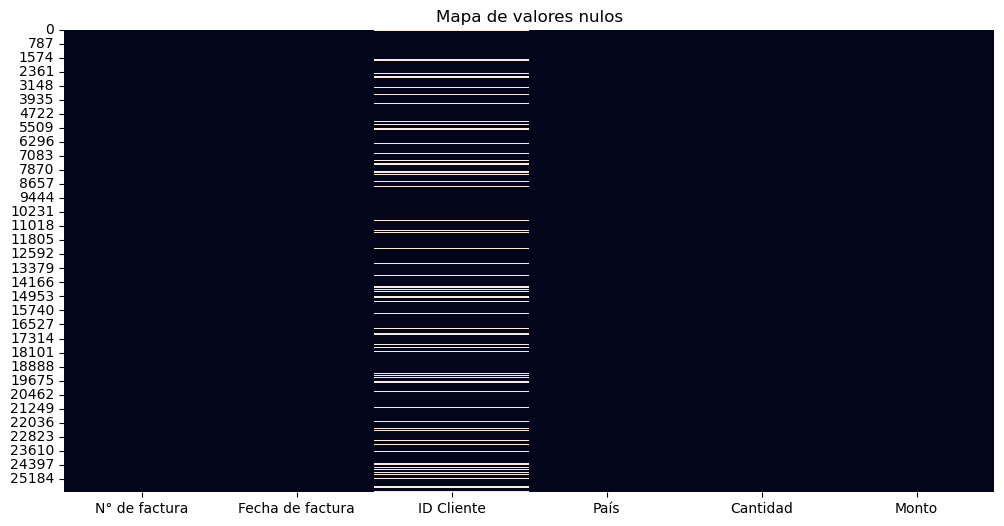

In [12]:
#Heatmap de valores nulos
plt.figure(figsize=(12,6))
sns.heatmap(dfVentas.isnull(), cbar=False)
plt.title("Mapa de valores nulos")
plt.show()

In [13]:
# registros duplicados
dfVentas.duplicated().sum()

np.int64(10)

In [15]:
# eliminar duplicados
dfVentas = dfVentas.drop_duplicates()

In [16]:
dfVentas["Fecha de factura"] = pd.to_datetime(
    dfVentas["Fecha de factura"],
    errors="coerce"
)

In [17]:
dfVentas["Monto"] = (
    dfVentas["Monto"]
    .astype(str)
    .str.replace(",", ".", regex=False)
)

dfVentas["Monto"] = pd.to_numeric(
    dfVentas["Monto"],
    errors="coerce"
)

In [18]:
canceladas = dfVentas[
    dfVentas["N° de factura"]
    .astype(str)
    .str.startswith("C")
]

print("Facturas canceladas:", len(canceladas))

Facturas canceladas: 3837


In [19]:
dfVentas["Cancelada"] = (
    dfVentas["N° de factura"]
    .astype(str)
    .str.startswith("C")
)

In [20]:
dfVentas[dfVentas["Cantidad"] < 0]

,N° de factura,Fecha de factura,ID Cliente,País,Cantidad,Monto,Cancelada
2,C570727,2021-10-12 11:32:00,12471.0,Germany,-1,-1.45,True
10,C543628,2021-02-10 15:51:00,16558.0,United Kingdom,-5,-9.25,True
16,542418,2021-01-27 17:39:00,NaN,United Kingdom,-17,0.00,False
17,C553508,2021-05-17 13:44:00,14000.0,United Kingdom,-3,-1.95,True
20,C577693,2021-11-21 11:48:00,12628.0,Germany,-3,-16.85,True
...,...,...,...,...,...,...,...
25943,C557061,2021-06-16 14:55:00,14895.0,United Kingdom,-5,-14.75,True
25944,C562147,2021-08-03 10:47:00,16180.0,United Kingdom,-7,-18.35,True
25947,C553519,2021-05-17 14:16:00,18218.0,United Kingdom,-2,-9.90,True
25948,C556518,2021-06-13 10:53:00,16794.0,United Kingdom,-2,-12.70,True


In [21]:
dfVentas[dfVentas["Monto"] < 0]

,N° de factura,Fecha de factura,ID Cliente,País,Cantidad,Monto,Cancelada
2,C570727,2021-10-12 11:32:00,12471.0,Germany,-1,-1.45,True
10,C543628,2021-02-10 15:51:00,16558.0,United Kingdom,-5,-9.25,True
17,C553508,2021-05-17 13:44:00,14000.0,United Kingdom,-3,-1.95,True
20,C577693,2021-11-21 11:48:00,12628.0,Germany,-3,-16.85,True
22,C547309,2021-03-22 11:17:00,17416.0,United Kingdom,-12,-45.00,True
...,...,...,...,...,...,...,...
25939,C572450,2021-10-24 12:35:00,NaN,United Kingdom,-2,-278.15,True
25943,C557061,2021-06-16 14:55:00,14895.0,United Kingdom,-5,-14.75,True
25944,C562147,2021-08-03 10:47:00,16180.0,United Kingdom,-7,-18.35,True
25947,C553519,2021-05-17 14:16:00,18218.0,United Kingdom,-2,-9.90,True


In [22]:
Q1 = dfVentas["Cantidad"].quantile(0.25)
Q3 = dfVentas["Cantidad"].quantile(0.75)

IQR = Q3 - Q1

lim_inf = Q1 - 1.5 * IQR
lim_sup = Q3 + 1.5 * IQR

outliers_cantidad = dfVentas[
    (dfVentas["Cantidad"] < lim_inf) |
    (dfVentas["Cantidad"] > lim_sup)
]

print("Outliers cantidad:", len(outliers_cantidad))

Outliers cantidad: 1847


In [23]:
Q1 = dfVentas["Monto"].quantile(0.25)
Q3 = dfVentas["Monto"].quantile(0.75)

IQR = Q3 - Q1

lim_inf = Q1 - 1.5 * IQR
lim_sup = Q3 + 1.5 * IQR

outliers_monto = dfVentas[
    (dfVentas["Monto"] < lim_inf) |
    (dfVentas["Monto"] > lim_sup)
]

print("Outliers monto:", len(outliers_monto))

Outliers monto: 1975


In [24]:
dfLimpio = dfVentas[
    ~dfVentas["Cancelada"]
].copy()

In [25]:
dfLimpio = dfLimpio[
    dfLimpio["Cantidad"] > 0
]

In [26]:
dfLimpio = dfLimpio[
    dfLimpio["Monto"] > 0
]

In [27]:
dfLimpio["ID Cliente"] = (
    dfLimpio["ID Cliente"]
    .fillna(dfLimpio["ID Cliente"].median())
)

In [28]:
dfLimpio["Año"] = dfLimpio["Fecha de factura"].dt.year

dfLimpio["Mes"] = dfLimpio["Fecha de factura"].dt.month

In [29]:
dfLimpio.shape

(20002, 9)

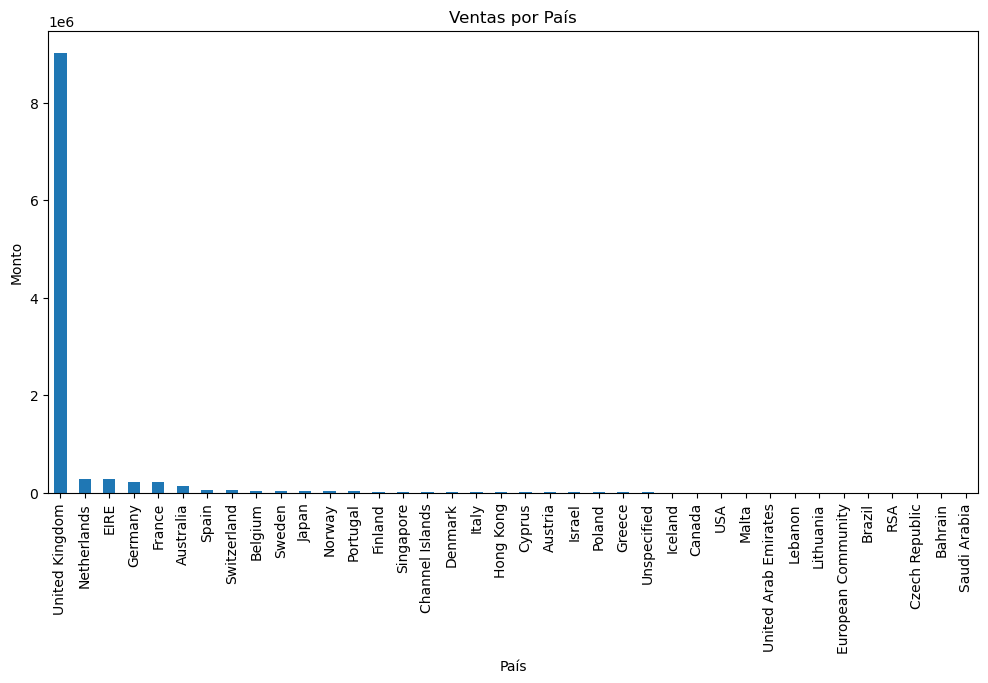

In [30]:
ventas_pais = (
    dfLimpio
    .groupby("País")["Monto"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12,6))
ventas_pais.plot(kind="bar")

plt.title("Ventas por País")
plt.xlabel("País")
plt.ylabel("Monto")
plt.show()

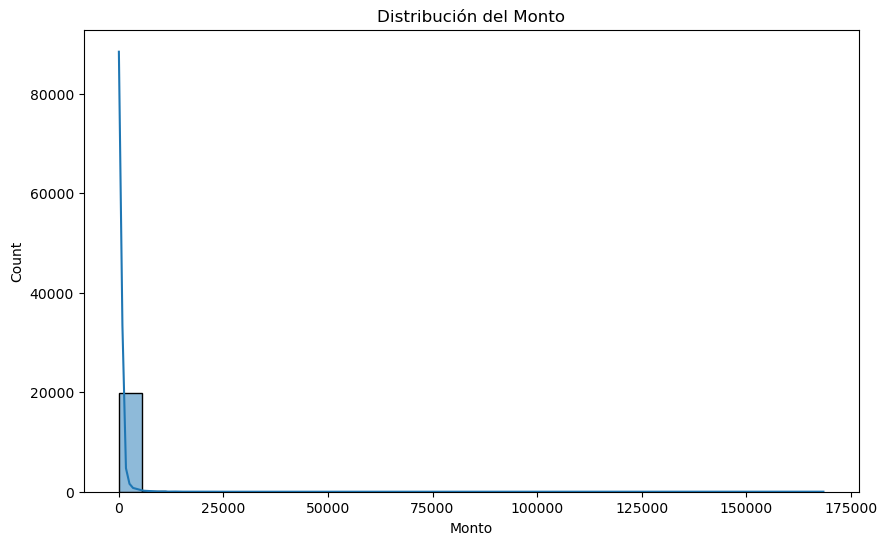

In [31]:
plt.figure(figsize=(10,6))

sns.histplot(
    dfLimpio["Monto"],
    bins=30,
    kde=True
)

plt.title("Distribución del Monto")
plt.xlabel("Monto")
plt.show()

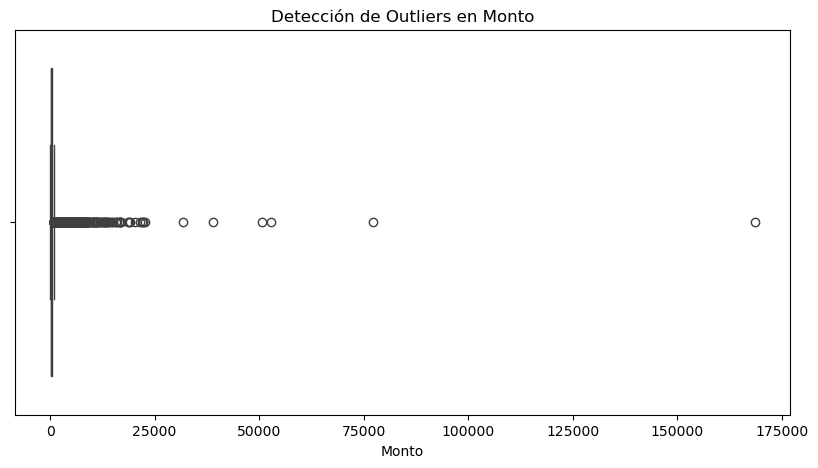

In [32]:
plt.figure(figsize=(10,5))

sns.boxplot(
    x=dfLimpio["Monto"]
)

plt.title("Detección de Outliers en Monto")
plt.show()

# CONCLUSIONES

"""
1. Durante el análisis se identificaron problemas de calidad de datos como
valores nulos, registros duplicados, facturas canceladas, datos inválidos y
problemas en los formatos de algunas columnas.

2. Se aplicaron técnicas de limpieza y transformación para mejorar la calidad
del dataset, incluyendo la eliminación de duplicados, la conversión de tipos
de datos y el tratamiento de registros inconsistentes.

3. El análisis de anomalías mediante la detección de outliers permitió
identificar valores atípicos que podrían afectar los resultados de los análisis
estadísticos y modelos predictivos.
